# 03: curves

`fxcarry.curves` is one object, `SpotForward`, which holds aligned spot and outright forward
quotes at one tenor. Every column is stored in dollars per foreign currency unit: when a rate
rises the foreign currency has gained, never the dollar, so one cross-sectional formula works
across the whole panel instead of needing a different sign convention for each pair the market
happens to quote the other way round. Carry, both return conventions, and the covered-parity
basis are all properties of this one object, which is why every later notebook in this series
starts from it.

In [1]:
import pathlib
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore", category=FutureWarning)

# nbconvert runs with this notebook's folder as the working directory, so walk up
# rather than assume how deep the notebook sits.
ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
            if (p / "data" / "raw").is_dir())
DATA = ROOT / "data" / "raw"
TAU = 1.0 / 12.0

## Building the panel: `SpotForward.from_quotes`

`from_quotes` takes spot and forward points as the market publishes them, one two-sided
`Quotes` panel each. It keeps only the currencies the spot pull, the points pull and the
catalog all agree on, builds the outright forward from the native spot and the native points,
and only then inverts spot and forward together for whichever currencies are not already
quoted dollars per foreign unit. Points scale a native quote, not a dollar one, so the outright
has to exist before anything gets reciprocated. The next section shows what happens when that
order is reversed.

In [2]:
from fxcarry import Catalog, ParquetSource, SpotForward

catalog = Catalog.default()
source = ParquetSource(DATA / "spot_daily.parquet", DATA / "fwd_points_1m_daily.parquet")
spot = source.quotes(catalog.label_map("spot"), freq="M")
points = source.quotes(catalog.label_map("forward", "1M"), freq="M")
curves = SpotForward.from_quotes(spot, points, catalog, TAU)
print(f"{len(curves.currencies)} currencies, {len(curves.spot.index)} months, "
      f"{curves.spot.index[0]:%Y-%m} to {curves.spot.index[-1]:%Y-%m}")
print(curves.currencies)

23 currencies, 513 months, 1983-11 to 2026-07
['AUD', 'CAD', 'CHF', 'CZK', 'DKK', 'EUR', 'GBP', 'HKD', 'HUF', 'JPY', 'KRW', 'KWD', 'MXN', 'MYR', 'NOK', 'NZD', 'PHP', 'PLN', 'SAR', 'SEK', 'SGD', 'THB', 'ZAR']


## Order matters: points scale the native quote

Forward points are a difference from spot, quoted in the same units as the native rate, so
applying them needs spot still in that native form. Invert first and add points after, and a
native-sized correction lands on a reciprocal on a completely different scale: the result does
not even come out positive. `Currency.outright` is always called on native spot and native
points; if inversion is needed at all, it happens to the result, never to an input.

In [3]:
jpy = catalog["JPY"]
s_native, p_native = 157.20, -40.85
right = 1.0 / jpy.outright(s_native, p_native)
wrong = 1.0 / s_native + p_native / jpy.point_scale
print(f"points applied then inverted: {right:.8f} dollars per yen")
print(f"inverted then points applied: {wrong:+.8f}, which is not even positive")

points applied then inverted: 0.00637790 dollars per yen
inverted then points applied: -0.40213868, which is not even positive


## `log_discount` and `carry`: the sign is the point

$$\text{carry}_t = -\frac{\log F_t - \log S_t}{\tau}$$

`log_discount` is the log of forward over spot. When it is positive, the foreign currency is
dear forward: the market charges more to buy it for later delivery than to buy it today.
`carry` is minus that, divided by the tenor, and the sign is deliberate. A forward priced above
spot is a forward market charging to deliver a currency later, and under covered parity that
means the currency pays a lower rate than the dollar, so being dear forward is negative carry.
In the sorted list below, the currencies at the top are the ones the forward market prices at a
discount to spot: they carry positive. The ones at the bottom are dear forward and carry
negative.

In [4]:
print(curves.carry.iloc[-1].dropna().sort_values(ascending=False).round(4).head(6))
print()
print(curves.carry.iloc[-1].dropna().sort_values().round(4).head(4))

MXN    0.0314
ZAR    0.0310
HUF    0.0176
PHP    0.0076
AUD    0.0066
NOK    0.0046
Name: 2026-07-31 00:00:00, dtype: float64

CHF   -0.0403
JPY   -0.0292
SGD   -0.0256
SEK   -0.0202
Name: 2026-07-31 00:00:00, dtype: float64


## Two return conventions, one trade

`excess_return` is the log return on being long the foreign currency forward: the log of the
settlement spot minus the log of the forward struck one period earlier. `forward_return` is the
same trade as a simple return, settlement spot over the struck forward, minus one. They describe
one position, so $\log(1 + r_{\text{simple}})$ has to equal $r_{\log}$ up to floating point,
which is exactly what the check below tests, not a coincidence. `excess_return` is what a
sorted book sums, since log returns across months add. `forward_return` is what carries into an
option payoff, since a payoff written on a notional needs a return that multiplies the notional
directly rather than compounding through a logarithm.

In [5]:
log_r, simple_r = curves.excess_return, curves.forward_return
resid = (np.log1p(simple_r) - log_r).abs().max().max()
assert resid < 1e-10, "the two return conventions disagree"
print(f"log(1 + forward_return) equals excess_return to {resid:.2e}")
print(f"they differ from each other by up to {(simple_r - log_r).abs().max().max():.4f} "
      "in level, which is the usual second order gap")

log(1 + forward_return) equals excess_return to 9.02e-16
they differ from each other by up to 0.0293 in level, which is the usual second order gap


## Indexing: a return is stamped at settlement

A forward struck at $t$ is not realized until it settles, so the return it produces belongs on
row $t+1$, the date the market actually pays it out, not the date the position opened. `carry`
is different: it is a property of the quotes sitting on row $t$ itself and needs no future date
to exist. That is why one column has a valid observation a full period earlier than the other.
It is not a bug in either one. Asking `excess_return` to hold a value before the forward it
depends on has settled would be asking for a number the market has not produced yet.

In [6]:
print("carry first valid       ", curves.carry.dropna(how="all").index[0].date())
print("excess return first valid", curves.excess_return.dropna(how="all").index[0].date())

carry first valid        1983-12-31
excess return first valid 1984-01-31


## Decomposing the trade: carry plus spot move

Being long the forward earns two things over a month: the carry priced into the discount,
scaled by the tenor, and whatever spot itself does between the strike date and settlement.
`spot_return` isolates the second piece: the log change in spot alone, with no interest
component in it. Unlike the two return conventions above, this split is exact rather than
approximate: `carry` is built from the same log forward and log spot that `spot_return` and
`excess_return` are, so the terms telescope and the two columns below sum to `excess_return` to
floating point. The table lines the three columns up for one currency so the addition can be
checked by eye; where a row looks off in the last digit shown, that is the five-decimal rounding
on the display, not a gap in the identity itself.

In [7]:
one = pd.DataFrame({"carry x tau": curves.carry["AUD"] * TAU,
                    "spot move": curves.spot_return["AUD"].shift(-1),
                    "excess return": curves.excess_return["AUD"].shift(-1)})
resid = (one["carry x tau"] + one["spot move"] - one["excess return"]).abs().max()
assert resid < 1e-10, "carry plus spot move does not sum to excess return"
print(f"carry x tau plus spot move equals excess return to {resid:.2e}")
one.dropna().tail(4).round(5)

carry x tau plus spot move equals excess return to 1.39e-17


,carry x tau,spot move,excess return
2026-03-31,0.00038,0.04270,0.04308
2026-04-30,0.00055,-0.00222,-0.00168
2026-05-31,0.00059,-0.03772,-0.03714
2026-06-30,0.00058,0.01107,0.01165


## `net_excess_return`: crossing the spread

`excess_return` is computed off mid, a price nobody actually trades at. `net_excess_return`
prices the same trade at the bid and the ask a counterparty would actually quote, and it needs a
`side` argument because the two legs are not symmetric. Going long means buying the forward at
the ask and selling spot at the bid; going short means the reverse pair of sides. A currency's
spread is not symmetric around its mid either, so the two directions do not cost the same
amount, and without knowing the side there is no way to tell which quote each leg is meant to
cross. The gap between `excess_return` and `net_excess_return` is the round-trip cost of
dealing, annualized into basis points below.

In [8]:
gross = curves.excess_return
print("annualized cost of crossing, basis points")
print((((gross - curves.net_excess_return("long")).mean() * 12) * 1e4)
      .round(1).sort_values(ascending=False).head(6))

annualized cost of crossing, basis points
KWD    787.8
ZAR    457.9
HUF    456.1
PLN    349.5
CZK    296.7
NOK    278.5
dtype: float64


## `implied_foreign_rate` and `basis`: reading the forward instead of pulling a rate

Covered parity ties the forward discount to the interest differential, so the equation behind
`carry` can be read the other way round: given a domestic rate, the forward alone pins down
what the foreign rate would have to be for no-arbitrage to hold. `implied_foreign_rate` does
exactly that, adding the domestic rate to `carry`. This is why a panel this wide is possible at
all. A live money-market curve is not quoted for most of these currencies, but a two-sided
forward almost always is, so the library never has to go looking for a foreign rate that most of
these currencies do not publish.

`basis` compares that implied rate against a foreign rate that is actually quoted, where one
exists. Zero means the forward and the deposit market agree on what it costs to hold one
currency against the other. Away from zero, they do not.

In [9]:
bill = ParquetSource(DATA / "tbill_daily.parquet").series("GB1M Index", freq="M") / 100.0
quoted = ParquetSource(DATA / "fx_short_rate_daily.parquet").panel(
    catalog.label_map("rate", "3M"), freq="M") / 100.0
implied = curves.implied_foreign_rate(bill)
basis = curves.basis(quoted, bill)
print("implied 1M foreign rates, latest")
print(implied.iloc[-1].dropna().round(4).head(6))
print("\ncovered parity basis against the quoted 3M benchmark, latest")
print(basis.iloc[-1].dropna().round(4).head(6))

# Support for the caveat below: fewer currencies quote a 1M rate benchmark than a
# 3M one, which is why the comparison above reaches for 3M rather than matching
# the implied rate's own tenor.
print(f"\ncurrencies with a quoted 1M rate benchmark: {len(catalog.label_map('rate', '1M'))}")
print(f"currencies with a quoted 3M rate benchmark: {len(catalog.label_map('rate', '3M'))}")

implied 1M foreign rates, latest
AUD    0.0436
CAD    0.0204
CHF   -0.0033
CZK    0.0368
DKK    0.0176
EUR    0.0220
Name: 2026-07-31 00:00:00, dtype: float64

covered parity basis against the quoted 3M benchmark, latest
AUD   -0.0010
CZK   -0.0014
DKK   -0.0062
EUR   -0.0025
HUF   -0.0020
KRW    0.0007
Name: 2026-07-31 00:00:00, dtype: float64

currencies with a quoted 1M rate benchmark: 13
currencies with a quoted 3M rate benchmark: 18


## Reading the gap: a term mismatch, not only a basis

The comparison above is not clean. `implied_foreign_rate` here is built from a 1M bill and the
library's own 1M forward, so it is a 1M rate. The benchmark it is checked against is quoted at
3M, because a 3M benchmark covers more currencies in this panel than a 1M one does, as printed
above. A 3M rate and a 1M rate do not have to agree even when covered parity holds exactly,
since the two tenors price different pieces of the same yield curve. So the basis numbers above
bundle a genuine covered-parity gap together with whatever the 1M-to-3M curve looks like for
each currency on that date, and the plot below inherits the same mixture. Switching to a 1M
benchmark would not fix this either: most currencies here do not quote one, so a 1M comparison
would only shrink the panel down to the handful that do, not remove the mismatch for the rest.

## The basis, pictured

EUR, JPY and CHF all sit modestly negative for most of this window, which given the mismatch
above is at least partly the ordinary gap between a 1M curve and a 3M one rather than anything
more dramatic. What breaks that pattern is September 2008: all three hit the lowest point of
their entire sample in the same month, well outside the range any of them otherwise holds, then
recover over the following months. Three unrelated currencies moving together, and by that
much, in the same month is not the signature of ordinary term-structure noise. It lines up with
the point where dollar funding seized up after Lehman Brothers failed, and a covered-parity
basis is exactly the kind of number that would pick that up.

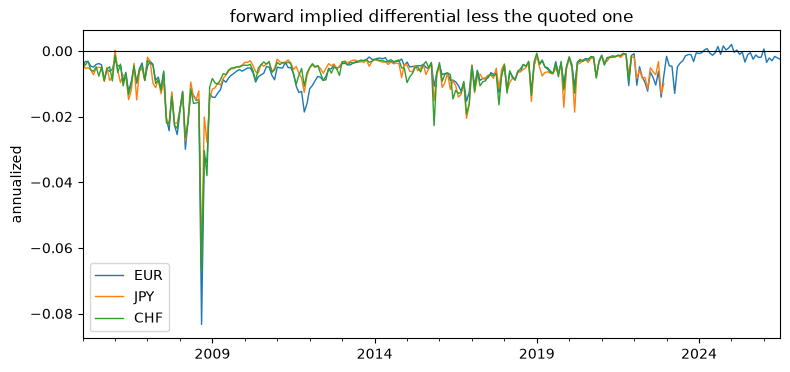

In [10]:
ax = basis[["EUR", "JPY", "CHF"]].loc["2005":].plot(figsize=(9, 4), linewidth=1)
ax.axhline(0.0, color="black", linewidth=0.8)
ax.set_title("forward implied differential less the quoted one")
ax.set_ylabel("annualized")
plt.show()

## Check yourself

**Which of `carry` and `excess_return` starts later, and why is that not a bug?** `carry` needs
only the quotes sitting on its own row, so it has a value from the very first month both sides
of the panel exist. `excess_return` needs a forward struck the period before to have already
settled, so its first valid row falls one month after `carry`'s, printed above. Nothing is
missing in either column. `excess_return` simply cannot exist before the trade it describes has
paid out.

**What does a wrong point scale do to the sorted book?** It does not fail loudly. Using the
default 10,000 divisor on a currency whose true scale is 100, the way JPY's is, shrinks the
points correction to a hundredth of its right size, so that currency's outright sits far closer
to spot than it should and its carry comes out near zero regardless of what covered parity
actually implies. A currency that belongs at either end of the sorted book would show up flat
instead, in the middle rather than a tail, and whatever currency genuinely sits near the middle
would get pushed toward one end to fill the gap. None of this raises an error anywhere in the
pipeline built above, since a wrong constant is still a number `outright` is happy to use. The
worked example in the order-matters section shows how far a mishandled scale can move a single
rate; a wrong `point_scale` does the same thing to every rate for that currency, silently, from
the first cell that touches it.

**Why does `net_excess_return` need a `side` argument?** Long and short are not mirror images
once the spread is added. Going long crosses the ask on the forward and the bid on spot; going
short crosses the opposite pair. A currency's spread is not symmetric around its mid, so the two
directions do not cost the same amount, and without a side argument the method has no way to
know which quote each leg is meant to cross.